# 04 - Outlier Handling

EDA found `Benefit per order` has 10.49% outliers by IQR at line item level, including a minimum of –$4,274.98. This notebook caps/winsorizes the aggregated (summed) version of this field for model training stability, and separately defines a priority formula safe value field for the secondary lens.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')

INPUT_PATH = Path('../../../data/processed/orders_clean.csv')
OUTPUT_PATH = Path('../../../data/processed/orders_final.csv')

orders_df = pd.read_csv(INPUT_PATH)
print(f"Shape: {orders_df.shape[0]:,} rows x {orders_df.shape[1]} columns")


Shape: 65,752 rows x 19 columns


## 1. Re check outlier extent at order level (post aggregation)

Summing line items to order level changes the distribution - re run the IQR check on the aggregated `Benefit per order` and `Sales`, since the line item level numbers from EDA no longer directly apply.


Sales: 152 outliers (0.23%) outside [-535.03, 1600.94]
Benefit per order: 5,188 outliers (7.89%) outside [-218.51, 384.98]


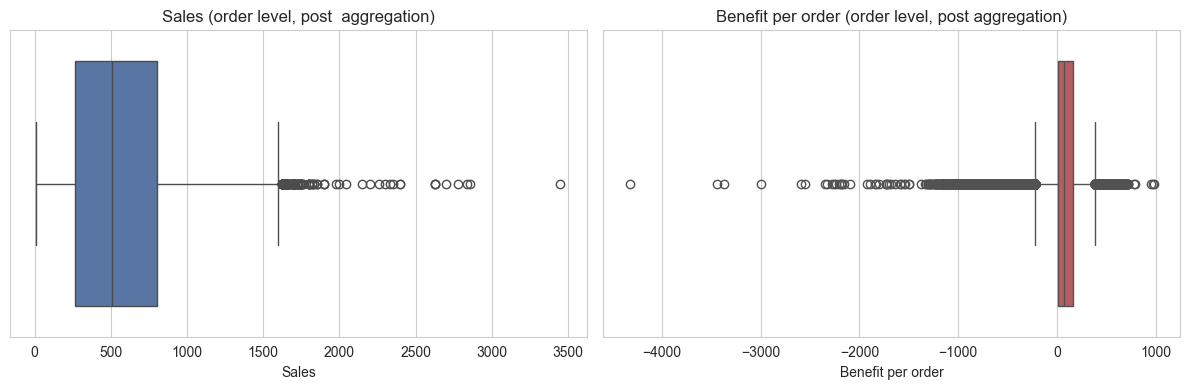

In [5]:
for col in ['Sales', 'Benefit per order']:
    q1, q3 = orders_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((orders_df[col] < lower) | (orders_df[col] > upper)).sum()
    pct_outliers = n_outliers / len(orders_df) * 100
    print(f"{col}: {n_outliers:,} outliers ({pct_outliers:.2f}%) outside [{lower:.2f}, {upper:.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=orders_df['Sales'], ax=axes[0], color='#4C72B0')
axes[0].set_title('Sales (order level, post  aggregation)')
sns.boxplot(x=orders_df['Benefit per order'], ax=axes[1], color='#C44E52')
axes[1].set_title('Benefit per order (order level, post aggregation)')
plt.tight_layout()
plt.show()


**What we found:**

**Aggregation changed the outlier picture for both columns, but especially for `Benefit per order`:**

| Column | Line item level (EDA) | Order level (post aggregation) |
|---|---|---|
| `Sales` | 488 outliers (0.27%) | 152 outliers (0.23%) |
| `Benefit per order` | 18,942 outliers (10.49%) | 5,188 outliers (7.89%) |

**Both outlier rates dropped after aggregation - this makes sense and is a good sign, not a red flag.** Summing multiple line items into one order level total has a smoothing effect: an unusually high or low value on a single line item gets averaged out against the order's other line items, so fewer *orders* end up looking extreme even though the underlying line item level variation is still real. `Benefit per order` shows the bigger shift (10.49% → 7.89%) simply because it had more extreme values to begin with (including that –$4,274.98 line item minimum).



## 2. Cap (winsorize) Benefit per order for model training

Cap at the 1st/99th percentile rather than dropping rows - this preserves all ~65,752 orders while preventing a handful of extreme values from dominating model training.


In [3]:
lower_cap = orders_df['Benefit per order'].quantile(0.01)
upper_cap = orders_df['Benefit per order'].quantile(0.99)

print(f"Capping Benefit per order to [{lower_cap:.2f}, {upper_cap:.2f}]")

orders_df['Benefit_per_order_capped'] = orders_df['Benefit per order'].clip(lower=lower_cap, upper=upper_cap)

n_capped = ((orders_df['Benefit per order'] < lower_cap) | (orders_df['Benefit per order'] > upper_cap)).sum()
print(f"Orders affected by capping: {n_capped} ({n_capped/len(orders_df)*100:.2f}%)")


Capping Benefit per order to [-645.22, 422.12]
Orders affected by capping: 1316 (2.00%)


## 3. Define the priority formula safe value field (secondary lens)

Per the decision to keep negative profit orders from distorting the priority ranking: use `Sales` (always positive, represents order size/importance) as the primary value term, and treat `Benefit per order` as a secondary signal rather than the sole driver of "value" in the risk × value formula.


In [6]:
# Priority score = predicted risk probability (added later) x order value
# define the value component the priority formula will use:
orders_df['priority_value_component'] = orders_df['Sales']  # Sales chosen over raw Benefit per order 

# Keep the capped profit figure available separately for reporting/analysis, not as the sole value driver
print(orders_df[['Order Id', 'Sales', 'Benefit per order', 'Benefit_per_order_capped', 'priority_value_component']].head())


   Order Id        Sales  Benefit per order  Benefit_per_order_capped  \
0         1   299.980011          88.790001                 88.790001   
1         2   579.980011         195.900002                195.900002   
2         4   699.850010         124.090000                124.090000   
3         5  1129.860039         390.089995                390.089995   
4         7   579.920013         203.929998                203.929998   

   priority_value_component  
0                299.980011  
1                579.980011  
2                699.850010  
3               1129.860039  
4                579.920013  


**Decision, reasoned here:** using `Sales` as the priority formula's value term avoids the sign confusion problem entirely - a large negative profit order won't be miscounted as "high value, deprioritise nothing." `Benefit per order` (capped) remains available in the dataset for reporting and any secondary analysis, but isn't the driver of the priority rank itself. 


## 4. Save the final preprocessed dataset

In [7]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
orders_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to: {OUTPUT_PATH.resolve()}")
print(f"Final shape: {orders_df.shape[0]:,} rows x {orders_df.shape[1]} columns")


Saved to: C:\Users\Ewis\Documents\Machine_learning_project\Heads-Up_IT3091\data\processed\orders_final.csv
Final shape: 65,752 rows x 21 columns
